# Week 4 Review — Conceptual Statistics Visualizations

This notebook generates the figures used in the Week 4 review. The goal is to make the **ideas** behind the statistical methods visible rather than turning the review into a list of formulas.

The visuals are organized around the same progression as the lectures and Lab 4:

**sampling → uncertainty → hypothesis testing → paired comparisons → multiple testing → distance/KNN → PCA**

The figures are intentionally synthetic, so the patterns are easy to control and discuss in class.

## 1. Imports and plotting defaults

The plotting code uses only `matplotlib` and `numpy` so that the notebook is easy to run in a standard course environment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 12,
})

## 2. The Central Limit Theorem: individual observations vs. sample means

The key distinction is between the **distribution of individual observations** and the **sampling distribution of the sample mean**.

Even when the underlying population is skewed, sample means become much more regular as the sample size increases under the conditions of the CLT.

In [1]:
# --------- Central Limit Theorem: sample mean ---------
# Adapted from the original dice/CLT example

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Number of i.i.d. random variables averaged in each sample
numIterations = np.asarray([1, 2, 5, 10, 50, 100])

experiment = "dice"  # valid values: "dice", "coins"
maxNumForExperiment = {"dice": 6, "coins": 2}

# Number of repeated samples used to build each sampling distribution
nSamp = 100000

k = maxNumForExperiment[experiment]

fig, fig_axes = plt.subplots(
    ncols=3,
    nrows=2,
    figsize=(10, 6),
    constrained_layout=True
)

population_mean = (1 + k) / 2

for i, N in enumerate(numIterations):

    # Draw N observations for each of nSamp repeated samples
    samples = np.random.randint(
        low=1,
        high=k + 1,
        size=(N, nSamp)
    )

    # Calculate the SAMPLE MEAN for each repeated sample
    y = samples.mean(axis=0)

    row = i // 3
    col = i % 3

    fig_axes[row, col].hist(
        y,
        bins=30,
        density=True
    )

    fig_axes[row, col].axvline(
        population_mean,
        linestyle="--",
        label="Population mean"
    )

    fig_axes[row, col].set_title(
        f"Sampling distribution of mean\n$n={N}$"
    )

    fig_axes[row, col].set_xlabel(r"$\bar{X}$")
    fig_axes[row, col].set_ylabel("Density")

    fig_axes[row, col].legend()

fig.suptitle(
    "CLT intuition: sample means become more approximately normal",
    fontsize=14
)

plt.savefig(
    "img.png",
    format="png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

### Teaching prompt

Ask students:

> **Which distribution changed shape here: the population or the distribution of the estimator?**

The population was kept fixed. What changes is the distribution of repeated **sample means**.

## 3. Why sample size reduces the standard error

The standard error of a mean scales as

$$
SE(\bar X)=\frac{\sigma}{\sqrt n}.
$$

This figure makes the $1/\sqrt n$ relationship visible.

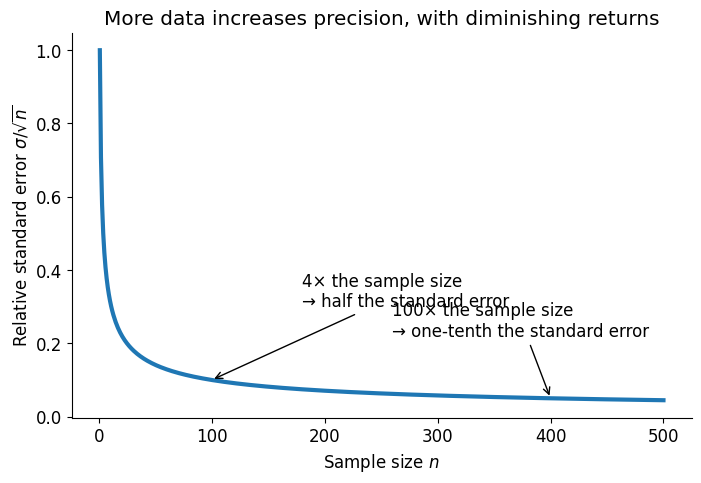

In [3]:
n = np.arange(1, 501)
se = 1 / np.sqrt(n)

fig, ax = plt.subplots()
ax.plot(n, se, linewidth=3)
ax.set_xlabel("Sample size $n$")
ax.set_ylabel(r"Relative standard error $\sigma/\sqrt{n}$")
ax.set_title("More data increases precision, with diminishing returns")
ax.annotate("4× the sample size\n→ half the standard error",
            xy=(100, 0.1), xytext=(180, 0.30),
            arrowprops={"arrowstyle": "->"})
ax.annotate("100× the sample size\n→ one-tenth the standard error",
            xy=(400, 0.05), xytext=(260, 0.22),
            arrowprops={"arrowstyle": "->"})
plt.show()

## 4. From the null hypothesis to a test statistic

A useful mental model is

$$
\text{test statistic}
\approx
\frac{\text{observed effect}-\text{null effect}}
{\text{expected variability}}.
$$

For a t-test, this becomes a signal-to-noise quantity. The same observed difference can be much more or less convincing depending on the amount of variability.

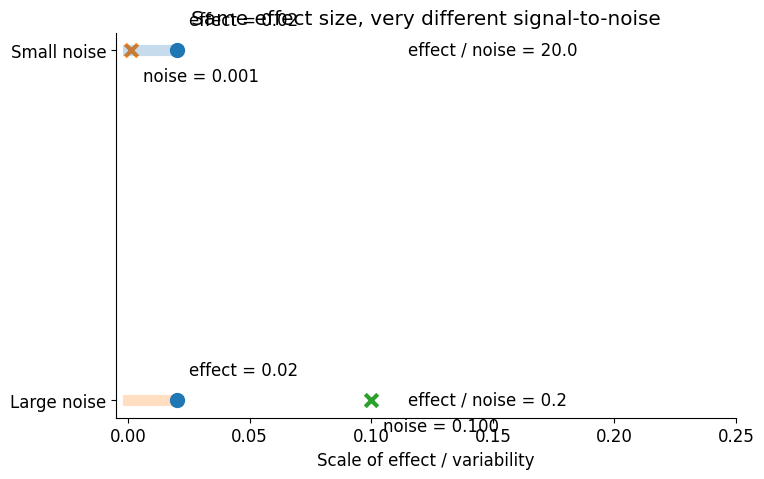

In [4]:
effects = np.array([0.02, 0.02])
noise = np.array([0.001, 0.10])
t_stats = effects / noise

fig, ax = plt.subplots(figsize=(8, 5))
y = np.array([1, 0])
ax.scatter(effects, y, s=100, zorder=3, label="Observed effect")
for yi, e, s, t in zip(y, effects, noise, t_stats):
    ax.plot([0, e], [yi, yi], linewidth=8, alpha=0.25)
    ax.scatter([s], [yi], s=80, marker="x", linewidth=3, label=None)
    ax.text(e + 0.005, yi + 0.07, f"effect = {e:.2f}")
    ax.text(s + 0.005, yi - 0.09, f"noise = {s:.3f}")
    ax.text(0.115, yi, f"effect / noise = {t:.1f}", va="center")

ax.set_yticks([0, 1], ["Large noise", "Small noise"])
ax.set_xlim(-0.005, 0.25)
ax.set_xlabel("Scale of effect / variability")
ax.set_title("Same effect size, very different signal-to-noise")
plt.show()

## 5. The p-value as a tail area under the null distribution

The p-value is easiest to visualize as an **area in a distribution generated under the null hypothesis**.

For a two-sided test, we count outcomes at least as extreme as the observed test statistic in either tail.

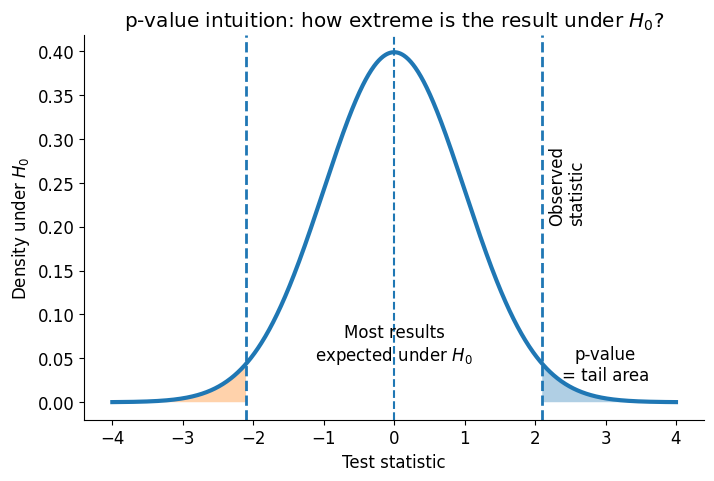

In [5]:
x = np.linspace(-4, 4, 1000)
y = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
observed = 2.1

fig, ax = plt.subplots()
ax.plot(x, y, linewidth=3)
ax.axvline(0, linestyle="--", linewidth=1.5)
ax.axvline(observed, linestyle="--", linewidth=2)
ax.axvline(-observed, linestyle="--", linewidth=2)

right = x >= observed
left = x <= -observed
ax.fill_between(x[right], y[right], alpha=0.35)
ax.fill_between(x[left], y[left], alpha=0.35)
ax.text(observed + 0.08, y.max() * 0.62, "Observed\nstatistic", rotation=90, va="center")
ax.text(0, y.max() * 0.12, "Most results\nexpected under $H_0$", ha="center")
ax.text(3.0, 0.025, "p-value\n= tail area", ha="center")

ax.set_xlabel("Test statistic")
ax.set_ylabel("Density under $H_0$")
ax.set_title("p-value intuition: how extreme is the result under $H_0$?")
plt.show()

### Important interpretation

The shaded area answers:

> **If $H_0$ were true, how often would we see a test statistic at least this extreme?**

It does **not** answer:

> "What is the probability that $H_0$ is true?"

That distinction is one of the most important concepts in the statistics lecture.

## 6. Effect size, uncertainty, and p-value are different things

A p-value is sensitive to both the **size of the observed effect** and the **uncertainty around it**.

This figure holds the effect fixed while changing uncertainty. It helps make the point that a smaller standard error makes a fixed effect look more extreme under the null model.

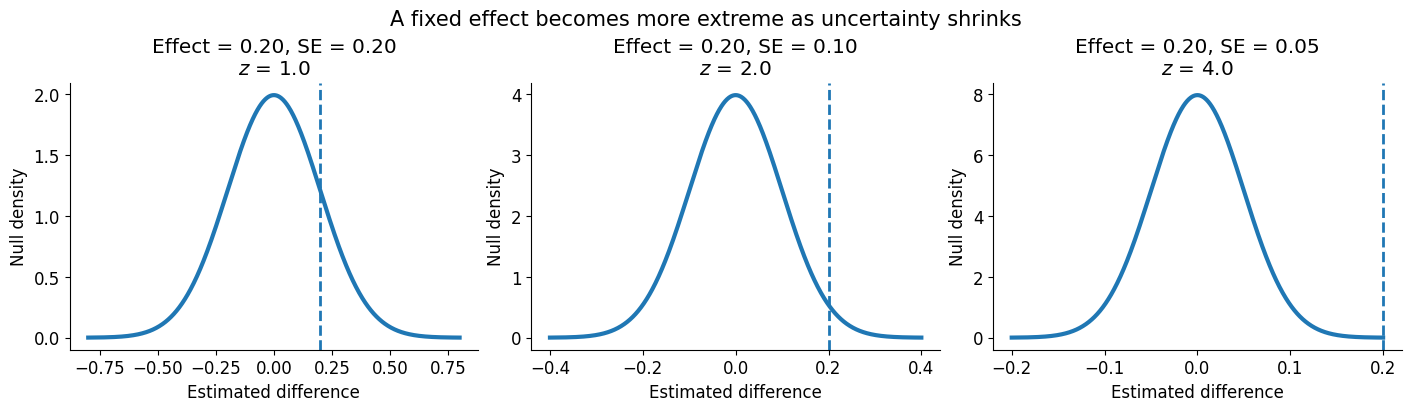

In [6]:
from scipy.stats import norm

effect = 0.20
standard_errors = [0.20, 0.10, 0.05]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

for ax, se in zip(axes, standard_errors):
    z = effect / se
    xx = np.linspace(-4 * se, 4 * se, 800)
    yy = norm.pdf(xx, loc=0, scale=se)
    ax.plot(xx, yy, linewidth=3)
    ax.axvline(effect, linestyle="--", linewidth=2)
    ax.set_title(f"Effect = {effect:.2f}, SE = {se:.2f}\n$z$ = {z:.1f}")
    ax.set_xlabel("Estimated difference")
    ax.set_ylabel("Null density")

fig.suptitle("A fixed effect becomes more extreme as uncertainty shrinks", fontsize=15)
plt.show()

## 7. Confidence intervals: magnitude + uncertainty

A confidence interval gives more information than a binary significant/not-significant label.

Here are three hypothetical model differences with different levels of precision.

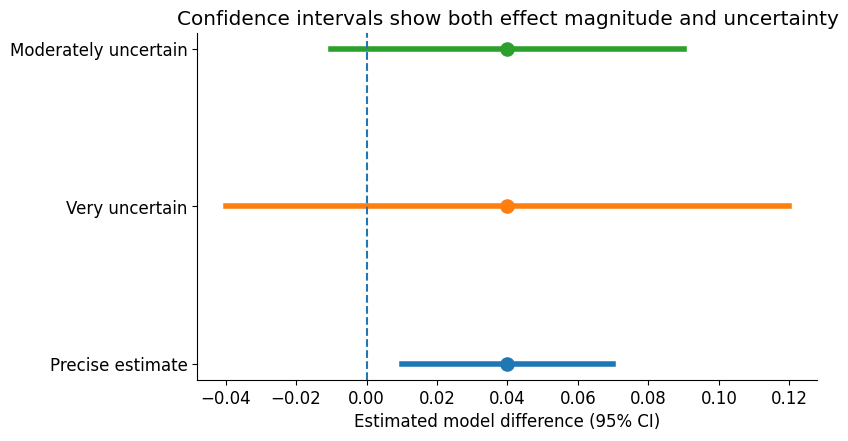

In [7]:
effects = np.array([0.04, 0.04, 0.04])
lows = np.array([0.01, -0.04, -0.01])
highs = np.array([0.07, 0.12, 0.09])
labels = ["Precise estimate", "Very uncertain", "Moderately uncertain"]

fig, ax = plt.subplots(figsize=(8, 4.5))
y = np.arange(len(labels))
for yi, e, lo, hi in zip(y, effects, lows, highs):
    ax.plot([lo, hi], [yi, yi], linewidth=4)
    ax.scatter([e], [yi], s=90, zorder=3)

ax.axvline(0, linestyle="--", linewidth=1.5)
ax.set_yticks(y, labels)
ax.set_xlabel("Estimated model difference (95% CI)")
ax.set_title("Confidence intervals show both effect magnitude and uncertainty")
plt.show()

## 8. Paired data: why the pairing matters

When two models are tested on the **same folds or datasets**, each pair shares the same challenge.

A paired test focuses on the within-pair differences:

$$
 d_i=A_i-B_i.
$$

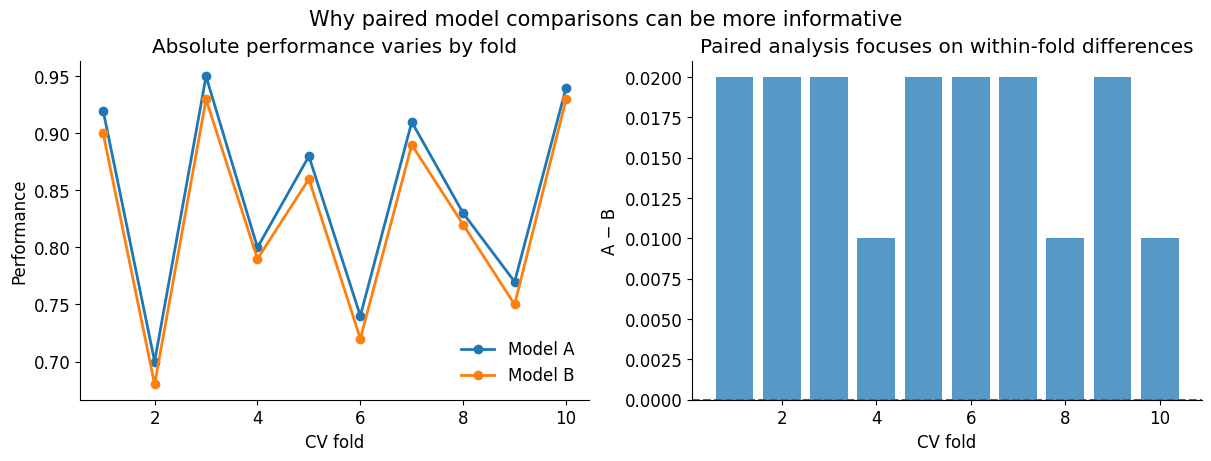

In [8]:
folds = np.arange(1, 11)
model_a = np.array([0.92, 0.70, 0.95, 0.80, 0.88, 0.74, 0.91, 0.83, 0.77, 0.94])
model_b = np.array([0.90, 0.68, 0.93, 0.79, 0.86, 0.72, 0.89, 0.82, 0.75, 0.93])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(folds, model_a, marker="o", linewidth=2, label="Model A")
axes[0].plot(folds, model_b, marker="o", linewidth=2, label="Model B")
axes[0].set_xlabel("CV fold")
axes[0].set_ylabel("Performance")
axes[0].set_title("Absolute performance varies by fold")
axes[0].legend(frameon=False)

ax = axes[1]
d = model_a - model_b
ax.axhline(0, linestyle="--", linewidth=1.5)
ax.bar(folds, d, alpha=0.75)
ax.set_xlabel("CV fold")
ax.set_ylabel("A − B")
ax.set_title("Paired analysis focuses on within-fold differences")

fig.suptitle("Why paired model comparisons can be more informative", fontsize=15)
plt.show()

## 9. Wilcoxon signed-rank intuition: rank the paired differences

The Wilcoxon signed-rank test does not treat the exact numerical magnitude of each difference in the same way as a t-test. It uses the **ranks of the absolute differences together with their signs**.

The teaching point is not to reproduce the algorithm by hand, but to see what information is being used.

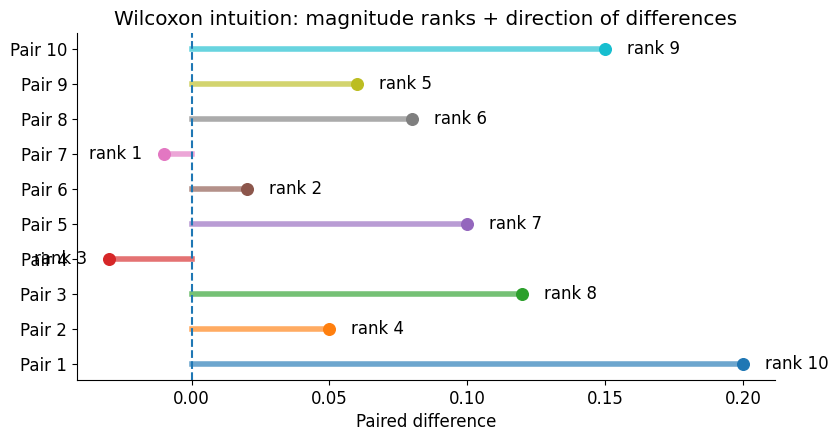

In [9]:
diffs = np.array([0.20, 0.05, 0.12, -0.03, 0.10, 0.02, -0.01, 0.08, 0.06, 0.15])
order = np.argsort(np.abs(diffs))
ranks = np.empty_like(order, dtype=float)
ranks[order] = np.arange(1, len(diffs) + 1)

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (d, r) in enumerate(zip(diffs, ranks)):
    ax.plot([0, d], [i, i], linewidth=4, alpha=0.65)
    ax.scatter([d], [i], s=70, zorder=3)
    ax.text(d + (0.008 if d >= 0 else -0.008), i, f"rank {int(r)}",
            va="center", ha="left" if d >= 0 else "right")

ax.axvline(0, linestyle="--", linewidth=1.5)
ax.set_yticks(range(len(diffs)), [f"Pair {i+1}" for i in range(len(diffs))])
ax.set_xlabel("Paired difference")
ax.set_title("Wilcoxon intuition: magnitude ranks + direction of differences")
plt.show()

## 10. McNemar: look at disagreements, not just accuracy

Suppose two models classify the same test observations. The four possible outcomes are:

| | Model B correct | Model B wrong |
|---|---:|---:|
| **Model A correct** | both correct | A only correct |
| **Model A wrong** | B only correct | both wrong |

McNemar focuses on the two **discordant** cells. If those are balanced, there is little evidence that one model systematically wins the disagreements.

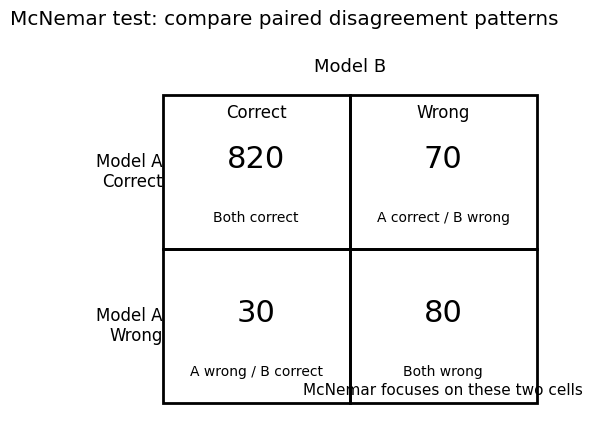

In [10]:
# Illustrative counts
both_correct = 820
both_wrong = 80
a_only = 70
b_only = 30

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

cells = [
    (0, 1, both_correct, "Both correct"),
    (1, 1, a_only, "A correct / B wrong"),
    (0, 0, b_only, "A wrong / B correct"),
    (1, 0, both_wrong, "Both wrong"),
]

for x, y, count, label in cells:
    ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, linewidth=2))
    ax.text(x + 0.5, y + 0.58, str(count), ha="center", va="center", fontsize=22)
    ax.text(x + 0.5, y + 0.20, label, ha="center", va="center", fontsize=10)

ax.text(1, 2.15, "Model B", ha="center", fontsize=13)
ax.text(0.5, 1.85, "Correct", ha="center")
ax.text(1.5, 1.85, "Wrong", ha="center")
ax.text(0.0, 1.5, "Model A\nCorrect", ha="right", va="center")
ax.text(0.0, 0.5, "Model A\nWrong", ha="right", va="center")
ax.text(1.5, 0.05, "McNemar focuses on these two cells", ha="center", fontsize=11)
ax.set_xlim(-0.8, 2.1)
ax.set_ylim(-0.1, 2.4)
ax.set_title("McNemar test: compare paired disagreement patterns")
plt.show()

## 11. ANOVA: between-group variation vs. within-group variation

The intuition behind one-way ANOVA is a comparison of two sources of variation:

$$
F \sim \frac{\text{between-group variation}}
{\text{within-group variation}}.
$$

If the group means are far apart relative to the spread within groups, the ratio becomes large.

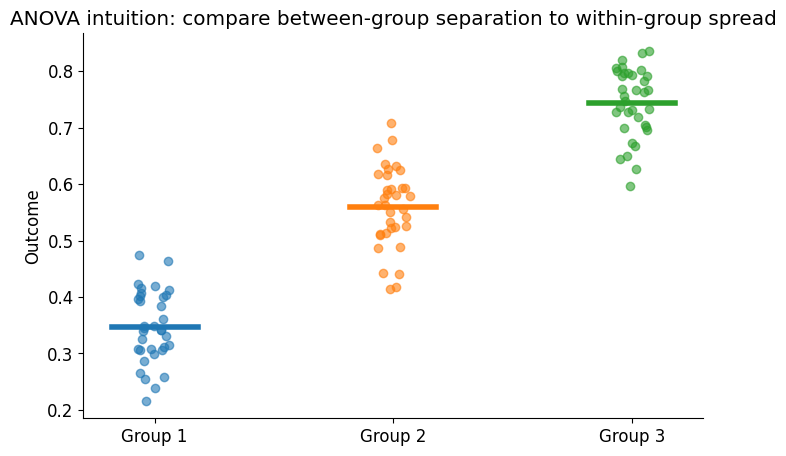

In [11]:
rng2 = np.random.default_rng(12)
g1 = rng2.normal(0.35, 0.07, 35)
g2 = rng2.normal(0.55, 0.07, 35)
g3 = rng2.normal(0.75, 0.07, 35)

groups = [g1, g2, g3]
labels = ["Group 1", "Group 2", "Group 3"]

fig, ax = plt.subplots(figsize=(8, 5))
for i, vals in enumerate(groups):
    jitter = rng2.uniform(-0.07, 0.07, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, alpha=0.6)
    ax.plot([i - 0.18, i + 0.18], [vals.mean(), vals.mean()], linewidth=4)

ax.set_xticks(range(3), labels)
ax.set_ylabel("Outcome")
ax.set_title("ANOVA intuition: compare between-group separation to within-group spread")
plt.show()

## 12. Multiple comparisons: many opportunities for a false positive

If every null hypothesis is true and each independent test uses $\alpha=0.05$, the chance of at least one false positive increases rapidly as the number of tests grows:

$$
P(\text{at least one false positive})
=
1-(1-0.05)^m.
$$

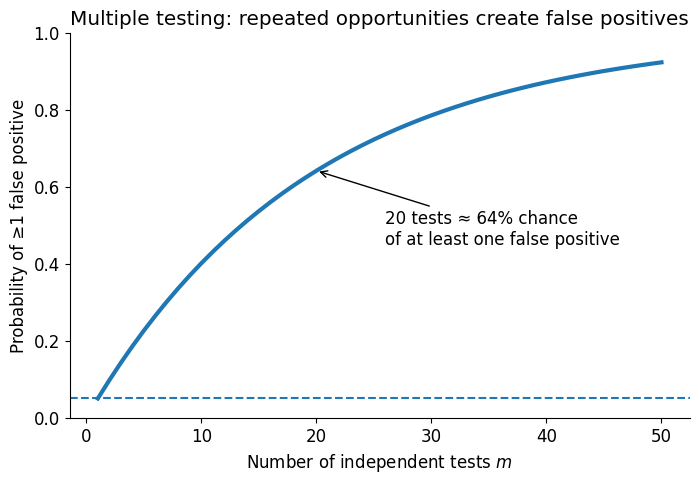

In [12]:
m = np.arange(1, 51)
familywise = 1 - (1 - 0.05) ** m

fig, ax = plt.subplots()
ax.plot(m, familywise, linewidth=3)
ax.axhline(0.05, linestyle="--", linewidth=1.5)
ax.set_xlabel("Number of independent tests $m$")
ax.set_ylabel("Probability of ≥1 false positive")
ax.set_ylim(0, 1)
ax.set_title("Multiple testing: repeated opportunities create false positives")
ax.annotate("20 tests ≈ 64% chance\nof at least one false positive",
            xy=(20, familywise[19]), xytext=(26, 0.45),
            arrowprops={"arrowstyle": "->"})
plt.show()

## 13. Why distance metrics change KNN neighborhoods

KNN does not have a single concept of "closest." The distance metric defines what counts as similar.

Below we compare Euclidean distance, Manhattan distance, and cosine similarity on the same small set of observations.

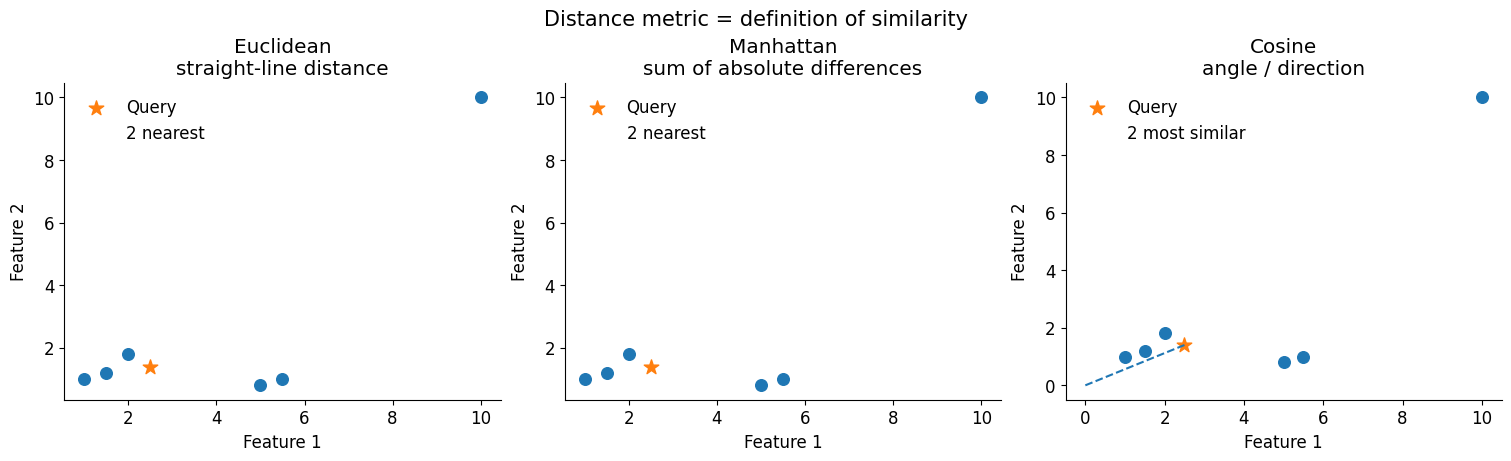

In [13]:
points = np.array([
    [1.0, 1.0],
    [1.5, 1.2],
    [2.0, 1.8],
    [5.0, 0.8],
    [5.5, 1.0],
    [10.0, 10.0],
])
query = np.array([2.5, 1.4])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# Euclidean
D_e = np.sqrt(((points - query) ** 2).sum(axis=1))
nearest_e = np.argsort(D_e)[:2]
axes[0].scatter(points[:, 0], points[:, 1], s=70)
axes[0].scatter(query[0], query[1], s=120, marker="*", label="Query")
axes[0].scatter(points[nearest_e, 0], points[nearest_e, 1], s=120, facecolors="none", linewidths=2, label="2 nearest")
axes[0].set_title("Euclidean\nstraight-line distance")
axes[0].legend(frameon=False)

# Manhattan
D_m = np.abs(points - query).sum(axis=1)
nearest_m = np.argsort(D_m)[:2]
axes[1].scatter(points[:, 0], points[:, 1], s=70)
axes[1].scatter(query[0], query[1], s=120, marker="*", label="Query")
axes[1].scatter(points[nearest_m, 0], points[nearest_m, 1], s=120, facecolors="none", linewidths=2, label="2 nearest")
axes[1].set_title("Manhattan\nsum of absolute differences")
axes[1].legend(frameon=False)

# Cosine in this 2D example
norms = np.linalg.norm(points, axis=1) * np.linalg.norm(query)
cos_sim = points @ query / norms
nearest_c = np.argsort(-cos_sim)[:2]
axes[2].scatter(points[:, 0], points[:, 1], s=70)
axes[2].scatter(query[0], query[1], s=120, marker="*", label="Query")
axes[2].scatter(points[nearest_c, 0], points[nearest_c, 1], s=120, facecolors="none", linewidths=2, label="2 most similar")
axes[2].plot([0, query[0]], [0, query[1]], linestyle="--", linewidth=1.5)
axes[2].set_title("Cosine\nangle / direction")
axes[2].legend(frameon=False)

for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

fig.suptitle("Distance metric = definition of similarity", fontsize=15)
plt.show()

### A useful class discussion

Ask students:

> **If I change only the distance metric, can KNN's prediction change?**

Yes. Changing the metric can change the nearest neighbors, and therefore the vote used for prediction.

That is why a distance metric is a **modeling assumption**, not merely a computational detail.

## 14. Feature scaling can change who the neighbors are

A large-unit feature can dominate a distance calculation.

The next example shows the same observations before and after standardization.

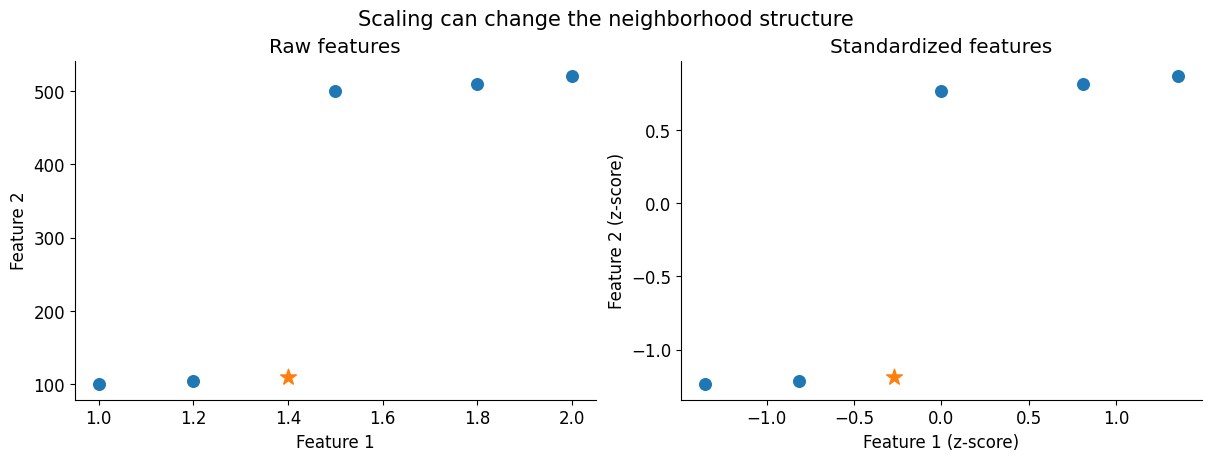

In [14]:
X = np.array([
    [1.0, 100.0],
    [1.2, 105.0],
    [1.5, 500.0],
    [1.8, 510.0],
    [2.0, 520.0],
])
q = np.array([1.4, 110.0])

raw_d = np.sqrt(((X - q) ** 2).sum(axis=1))
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
q_scaled = (q - X.mean(axis=0)) / X.std(axis=0)
scaled_d = np.sqrt(((X_scaled - q_scaled) ** 2).sum(axis=1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, pts, qq, dists, title in [
    (axes[0], X, q, raw_d, "Raw features"),
    (axes[1], X_scaled, q_scaled, scaled_d, "Standardized features"),
]:
    nearest = np.argsort(dists)[:2]
    ax.scatter(pts[:, 0], pts[:, 1], s=70)
    ax.scatter(qq[0], qq[1], marker="*", s=140)
    ax.scatter(pts[nearest, 0], pts[nearest, 1], s=120, facecolors="none", linewidths=2)
    ax.set_title(title)

axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[1].set_xlabel("Feature 1 (z-score)")
axes[1].set_ylabel("Feature 2 (z-score)")
fig.suptitle("Scaling can change the neighborhood structure", fontsize=15)
plt.show()

## 15. PCA: maximizing variance does not mean maximizing class separation

PCA is **unsupervised**. It finds directions of high variance without using the class labels.

The example below deliberately creates a situation where the direction with the largest variance is not the direction that best separates the two classes.

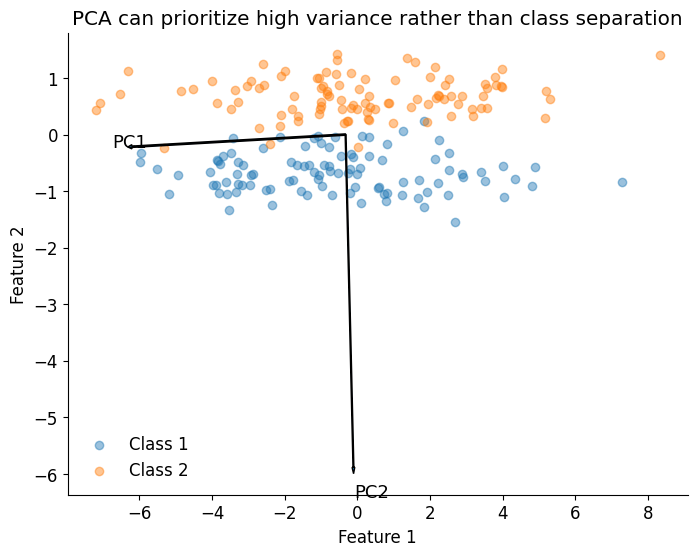

In [15]:
rng3 = np.random.default_rng(5)
n_per_class = 100

# Large shared variance along x; smaller class separation along y.
x1 = rng3.normal(0, 3.0, n_per_class)
y1 = rng3.normal(-0.7, 0.35, n_per_class)
x2 = rng3.normal(0, 3.0, n_per_class)
y2 = rng3.normal(0.7, 0.35, n_per_class)

X1 = np.column_stack([x1, y1])
X2 = np.column_stack([x2, y2])
X = np.vstack([X1, X2])
Xc = X - X.mean(axis=0)

cov = np.cov(Xc, rowvar=False)
evals, evecs = np.linalg.eigh(cov)
order = np.argsort(evals)[::-1]
pc1 = evecs[:, order[0]]
pc2 = evecs[:, order[1]]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X1[:, 0], X1[:, 1], alpha=0.45, label="Class 1")
ax.scatter(X2[:, 0], X2[:, 1], alpha=0.45, label="Class 2")
origin = X.mean(axis=0)
scale = 6
ax.arrow(origin[0], origin[1], scale * pc1[0], scale * pc1[1], width=0.025, length_includes_head=True)
ax.arrow(origin[0], origin[1], scale * pc2[0], scale * pc2[1], width=0.025, length_includes_head=True)
ax.text(*(origin + scale * pc1 * 1.07), "PC1", fontsize=13)
ax.text(*(origin + scale * pc2 * 1.07), "PC2", fontsize=13)
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_title("PCA can prioritize high variance rather than class separation")
ax.legend(frameon=False)
plt.show()

## 16. PCA: explained variance as a tradeoff

When we keep only the first few principal components, we trade dimensionality for retained variance.

The cumulative explained-variance curve makes that tradeoff explicit.

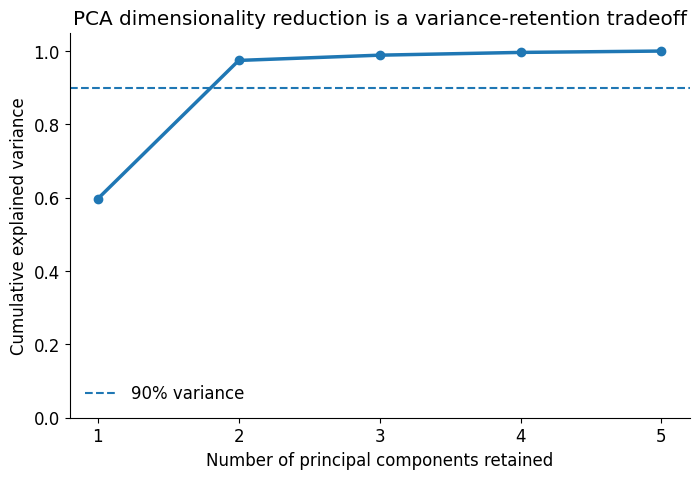

In [16]:
rng4 = np.random.default_rng(11)
# Correlated synthetic features
base = rng4.normal(size=(500, 4))
X = np.column_stack([
    base[:, 0] + 0.15 * rng4.normal(size=500),
    0.8 * base[:, 0] + 0.2 * base[:, 1] + 0.15 * rng4.normal(size=500),
    base[:, 1] + 0.15 * rng4.normal(size=500),
    0.5 * base[:, 1] + 0.1 * rng4.normal(size=500),
    0.3 * base[:, 0] + 0.2 * base[:, 2] + 0.1 * rng4.normal(size=500),
])
Xc = X - X.mean(axis=0)
cov = np.cov(Xc, rowvar=False)
evals = np.linalg.eigvalsh(cov)[::-1]
ratio = evals / evals.sum()
cumulative = np.cumsum(ratio)

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(ratio) + 1), cumulative, marker="o", linewidth=2.5)
ax.axhline(0.90, linestyle="--", linewidth=1.5, label="90% variance")
ax.set_xticks(np.arange(1, len(ratio) + 1))
ax.set_xlabel("Number of principal components retained")
ax.set_ylabel("Cumulative explained variance")
ax.set_ylim(0, 1.05)
ax.set_title("PCA dimensionality reduction is a variance-retention tradeoff")
ax.legend(frameon=False)
plt.show()

## 17. One final visual: what the statistical workflow is doing

The overall logic of the statistical part of model evaluation can be summarized visually:

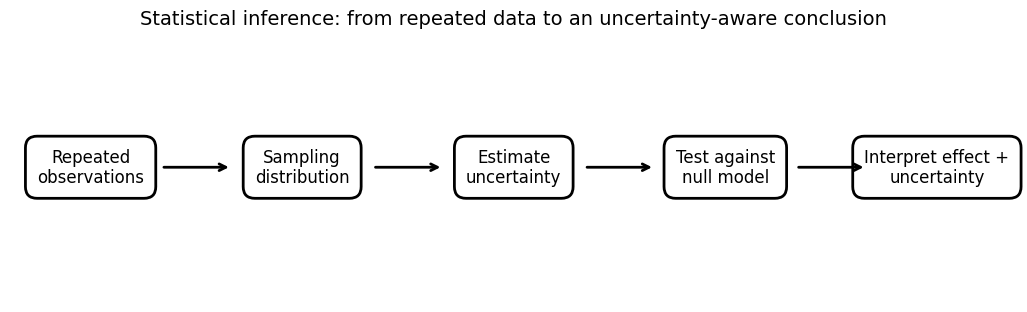

In [17]:
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.axis("off")

steps = [
    ("Repeated\nobservations", 0.08),
    ("Sampling\ndistribution", 0.29),
    ("Estimate\nuncertainty", 0.50),
    ("Test against\nnull model", 0.71),
    ("Interpret effect +\nuncertainty", 0.92),
]

for i, (label, x0) in enumerate(steps):
    ax.text(x0, 0.5, label, transform=ax.transAxes, ha="center", va="center",
            bbox={"boxstyle": "round,pad=0.7", "fill": False, "linewidth": 2}, fontsize=12)
    if i < len(steps) - 1:
        ax.annotate("", xy=(steps[i+1][1] - 0.07, 0.5), xytext=(x0 + 0.07, 0.5),
                    xycoords=ax.transAxes, textcoords=ax.transAxes,
                    arrowprops={"arrowstyle": "->", "linewidth": 2})

ax.set_title("Statistical inference: from repeated data to an uncertainty-aware conclusion", fontsize=14)
plt.show()

# Suggested ways to use these figures in class

### For the p-value figure
Ask students **before** explaining the definition:

> “What does the shaded area represent?”

Then ask:

> “What would have to change to make the shaded area smaller?”

### For the paired-test figure
Ask:

> “Why not throw all 20 scores into two groups and ignore which fold they came from?”

### For McNemar
Ask:

> “Two models have exactly the same accuracy. Could one still systematically outperform the other on the observations where they disagree?”

### For distance metrics
Ask students to predict which points become neighbors under each metric **before** showing the highlighted points.

### For PCA
Ask:

> “If PC1 explains 70% of the variance but the classes overlap on PC1, did PCA fail?”

The desired answer is **no**: PCA was optimizing variance, not class separation.